# Transfer Learning MobileNetV3-Small (zip apa saja)

Notebook ini **tidak terikat ke satu dataset**. Cukup unggah zip berisi gambar yang dikelompokkan per kelas, dan kelas, jumlah kelas, serta pembagian train/val/test dideteksi otomatis.

**Format zip yang didukung**
1. `kelas_a/ kelas_b/ ...` berisi gambar (boleh ada folder pembungkus di luar, atau file lain seperti metadata.csv).
2. `train/kelas_a/..  val/kelas_a/..  test/kelas_a/..` (sudah dibagi).
3. Kalau ada `metadata.csv` dengan kolom `split` (train/val/test), kolom itu dipakai. Kalau tidak ada, data dibagi acak 70/15/15 (stratified).

**Cara pakai**
1. Runtime → Change runtime type → **T4 GPU** → Save.
2. Jalankan sel dari atas ke bawah (Shift+Enter) dan jangan menekan stop saat sel berjalan.
3. **Ganti dataset:** unduh dulu hasil di sel terakhir, lalu jalankan ulang mulai **Sel 3 (unggah zip)** sampai bawah. Tidak perlu restart.

## 2. Pengaturan (boleh diubah)

In [13]:
SEED = 42
EPOCHS = 15
BS = 32
IMG = 224                  # ukuran input; coba 320 kalau objek di foto kecil (latensi naik)
USE_METADATA_SPLIT = True  # pakai kolom split di metadata.csv kalau ada

## 3. Unggah zip dataset
Klik **Choose files** lalu pilih zip-nya. Untuk ganti dataset, jalankan ulang sel ini dan sel-sel sesudahnya.

In [14]:
import os, re, glob, shutil, zipfile
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import files

IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
SPLIT_MAP = {"train": "train", "training": "train", "val": "val", "valid": "val",
             "validation": "val", "test": "test", "testing": "test"}

def list_images(folder):
    out = []
    for dp, dn, fn in os.walk(folder):
        dn[:] = [d for d in dn if not d.startswith((".", "__"))]
        out += [os.path.join(dp, f) for f in fn
                if f.lower().endswith(IMG_EXT) and not f.startswith(".")]
    return sorted(out)

def subdirs(folder):
    return sorted(d for d in os.listdir(folder)
                  if os.path.isdir(os.path.join(folder, d)) and not d.startswith((".", "__")))

def find_root(base):
    for dp, dn, fn in os.walk(base):
        dn[:] = [d for d in dn if not d.startswith((".", "__"))]
        kids = [d for d in dn if list_images(os.path.join(dp, d))]
        if len(kids) >= 2:
            return dp, sorted(kids)
    raise SystemExit("Struktur kelas tidak ketemu. Pastikan zip berisi minimal 2 folder kelas yang berisi gambar.")

def read_metadata_split(df):
    meta_path = None
    for dp, dn, fn in os.walk("data"):
        for f in fn:
            if f.lower() == "metadata.csv":
                meta_path = os.path.join(dp, f); break
        if meta_path: break
    if not meta_path:
        return None
    m = pd.read_csv(meta_path)
    cols = {c.lower(): c for c in m.columns}
    sc = cols.get("split")
    fc = next((cols[c] for c in ["nama_file", "filename", "file_name", "file", "image", "path"] if c in cols), None)
    kc = next((cols[c] for c in ["kelas", "label", "class", "kategori"] if c in cols), None)
    if not (sc and fc and kc):
        return None
    m = pd.DataFrame({"kelas": m[kc].astype(str),
                      "nama_file": m[fc].astype(str).map(os.path.basename),
                      "split": m[sc].astype(str).str.lower().map(SPLIT_MAP)}).dropna()
    m = m.drop_duplicates(["kelas", "nama_file"])
    out = df.drop(columns="split").merge(m, on=["kelas", "nama_file"], how="inner")
    if len(out) < 0.5 * len(df):          # metadata tidak cocok dengan folder
        return None
    return out

def prepare(zipname):
    shutil.rmtree("data", ignore_errors=True)
    with zipfile.ZipFile(zipname) as z:
        z.extractall("data")
    root, kids = find_root("data")
    items = []
    if all(k.lower() in SPLIT_MAP for k in kids):
        struktur = "folder sudah dibagi train/val/test"
        for sp in kids:
            for cls in subdirs(os.path.join(root, sp)):
                for p in list_images(os.path.join(root, sp, cls)):
                    items.append((p, cls, SPLIT_MAP[sp.lower()]))
    else:
        struktur = "satu folder per kelas"
        for cls in kids:
            for p in list_images(os.path.join(root, cls)):
                items.append((p, cls, None))
    df = pd.DataFrame(items, columns=["path", "kelas", "split"])
    df["nama_file"] = df.path.map(os.path.basename)
    print("Struktur  :", struktur)
    print("Total file:", len(df), "| kelas:", sorted(df.kelas.unique()))

    if df.split.notna().all() and set(df.split) == {"train", "val", "test"}:
        print("Split     : dari struktur folder")
    else:
        full = df.copy()
        ms = read_metadata_split(full) if USE_METADATA_SPLIT else None
        if ms is not None and set(ms.split) == {"train", "val", "test"}:
            print(f"Split     : dari kolom split di metadata.csv ({len(full) - len(ms)} file tidak ada di metadata, dibuang)")
            df = ms
        else:
            df = full
            if df.kelas.value_counts().min() < 10:
                raise SystemExit("Ada kelas dengan kurang dari 10 gambar, terlalu sedikit untuk dibagi train/val/test.")
            tr, tmp = train_test_split(df.index, test_size=0.30, stratify=df.kelas, random_state=SEED)
            va, te = train_test_split(tmp, test_size=0.50, stratify=df.kelas[tmp], random_state=SEED)
            df["split"] = "train"; df.loc[va, "split"] = "val"; df.loc[te, "split"] = "test"
            print("Split     : acak 70/15/15 (tidak ada info split di zip)")
            print("            Catatan: foto yang mirip (satu sesi) bisa jatuh di train dan test sekaligus, jadi akurasi bisa terlihat terlalu bagus.")
    return df.reset_index(drop=True)

for f in glob.glob("*.zip"):
    os.remove(f)
up = files.upload()
zipname = list(up.keys())[0]
assert zipname.lower().endswith(".zip"), "File yang diunggah harus berformat .zip"
TAG = re.sub(r"\W+", "_", os.path.splitext(os.path.basename(zipname))[0]).strip("_")
df = prepare(zipname)
print("TAG hasil :", TAG)

Saving dataset_raw (1).zip to dataset_raw (1).zip
Struktur  : satu folder per kelas
Total file: 359 | kelas: ['huruf_angka', 'panah']
Split     : dari kolom split di metadata.csv (0 file tidak ada di metadata, dibuang)
TAG hasil : dataset_raw_1


## 4. Cek dataset
Pastikan jumlah per kelas dan cuplikan gambarnya benar, dan baca peringatan kalau ada.

kelas  huruf_angka  panah  Total
split                           
train          100     95    195
val             29     52     81
test            51     32     83
TOTAL          180    179    359

Total keseluruhan: 359 gambar
  huruf_angka: 180 gambar (50.1%)
  panah: 179 gambar (49.9%)



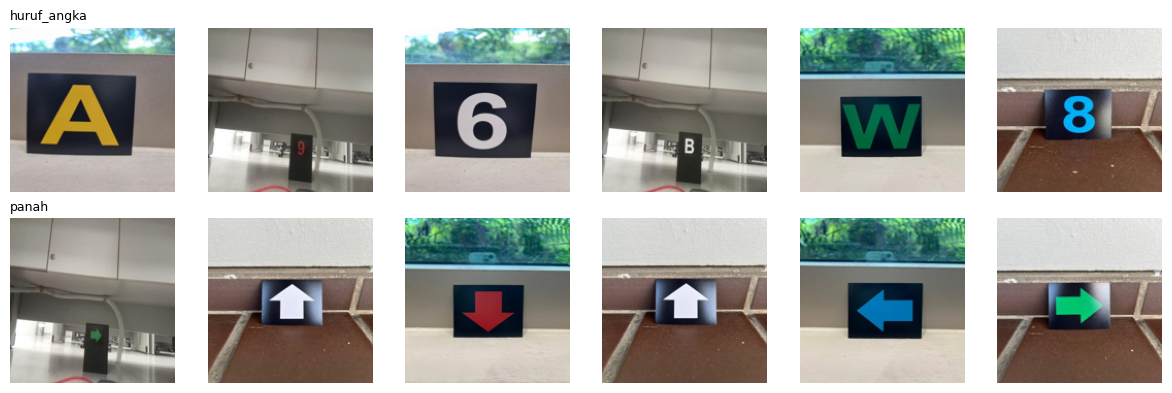

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

tabel = pd.crosstab(df["split"], df["kelas"]).reindex(["train", "val", "test"]).fillna(0).astype(int)
tabel["Total"] = tabel.sum(axis=1)
tabel.loc["TOTAL"] = tabel.sum()
print(tabel)
print(f"\nTotal keseluruhan: {len(df)} gambar")
for k, n in df.kelas.value_counts().items():
    print(f"  {k}: {n} gambar ({n / len(df) * 100:.1f}%)")
print()

kecil = df.kelas.value_counts()
for k, n in kecil.items():
    if n < 50:
        print(f"PERINGATAN: kelas '{k}' hanya {n} gambar (tugas meminta minimal 50 per kelas)")
if kecil.max() / kecil.min() > 3:
    print(f"PERINGATAN: kelas tidak seimbang (rasio {kecil.max()/kecil.min():.1f}:1). Hasil dilaporkan dengan balanced accuracy dan loss diberi bobot.")

kelas = sorted(df.kelas.unique())
n_show = min(6, df.kelas.value_counts().min())
fig, axes = plt.subplots(len(kelas), n_show, figsize=(2 * n_show, 2 * len(kelas)), squeeze=False)
for r, k in enumerate(kelas):
    for c, p in enumerate(df[df.kelas == k].sample(n_show, random_state=1).path):
        im = Image.open(p); im.thumbnail((160, 160))
        axes[r, c].imshow(im); axes[r, c].axis("off")
    axes[r, 0].set_title(k, loc="left", fontsize=9)
plt.tight_layout(); plt.show()

## 5. Training
Pastikan output pertama `Device: cuda`. Mode yang dilatih diatur lewat variabel `MODES` di baris atas sel ini (default: hanya `finetune`). Loss diberi bobot kelas, epoch terbaik dipilih dari balanced accuracy validasi. Sel ini hanya melatih; grafik dan evaluasi ada di sel-sel berikutnya, jadi kalau ada error di sana tidak perlu training ulang.

In [16]:
import time, copy, numpy as np, pandas as pd, torch, torch.nn as nn
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import balanced_accuracy_score, f1_score

MODES = ["finetune"]   # pilihan: "scratch", "freeze", "finetune" (boleh lebih dari satu)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
torch.manual_seed(SEED); np.random.seed(SEED)

CLASSES = sorted(df.kelas.unique()); NC = len(CLASSES)
c2i = {c: i for i, c in enumerate(CLASSES)}

mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
tf_train = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(0.3, 0.3, 0.2),
    transforms.ToTensor(), transforms.Normalize(mean, std)])
tf_eval = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(), transforms.Normalize(mean, std)])

class DS(Dataset):
    def __init__(self, d, tf):
        self.paths = d.path.tolist(); self.y = [c2i[k] for k in d.kelas]; self.tf = tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("RGB")), self.y[i]

d_tr = DS(df[df.split == "train"], tf_train)
d_va = DS(df[df.split == "val"],   tf_eval)
d_te = DS(df[df.split == "test"],  tf_eval)
train_dl = DataLoader(d_tr, batch_size=BS, shuffle=True, num_workers=2)
val_dl   = DataLoader(d_va, batch_size=BS, num_workers=2)
test_dl  = DataLoader(d_te, batch_size=BS, num_workers=2)
print("train/val/test =", len(d_tr), len(d_va), len(d_te))
print("jumlah batch per epoch (train):", len(train_dl))

cnt = np.bincount(d_tr.y, minlength=NC)
cls_w = torch.tensor(cnt.sum() / (NC * np.maximum(cnt, 1)), dtype=torch.float32).to(device)
print("jumlah train per kelas:", dict(zip(CLASSES, cnt.tolist())), "| bobot loss:", [round(w, 2) for w in cls_w.tolist()])
loss_fn = nn.CrossEntropyLoss(weight=cls_w)

def build_model(mode):
    if mode == "scratch":
        m = models.mobilenet_v3_small(weights=None)
    else:
        m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, NC)
    if mode == "freeze":
        for p in m.features.parameters():
            p.requires_grad = False
    return m.to(device)

LR = {"scratch": 1e-3, "freeze": 1e-3, "finetune": 1e-4}

def evaluate(m, dl):
    """Mengembalikan label asli, prediksi, dan loss rata-rata pada dataloader dl."""
    m.eval(); ys, ps, tot = [], [], 0.0
    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            out = m(x)
            tot += loss_fn(out, y).item() * y.size(0)
            ps += out.argmax(1).cpu().tolist(); ys += y.cpu().tolist()
    return np.array(ys), np.array(ps), tot / len(dl.dataset)

def run(mode):
    m = build_model(mode)
    n_train = sum(p.numel() for p in m.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in m.parameters())
    print(f"\n=== Mode: {mode} | parameter dilatih: {n_train:,} dari {n_total:,} | lr={LR[mode]} ===")
    opt = torch.optim.Adam([p for p in m.parameters() if p.requires_grad], lr=LR[mode])
    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_bal", "val_f1"]}
    best, best_state, best_ep = -1, None, 0
    t0 = time.time()
    for ep in range(EPOCHS):
        m.train()
        if mode == "freeze":
            m.features.eval()      # batchnorm di backbone ikut dibekukan
        c = n = 0; tl = 0.0
        for x, y in train_dl:      # satu putaran = satu batch
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = m(x); loss = loss_fn(out, y)
            loss.backward(); opt.step()
            tl += loss.item() * y.size(0)
            c += (out.argmax(1) == y).sum().item(); n += y.size(0)
        yv, pv, vl = evaluate(m, val_dl)
        row = dict(train_loss=tl / n, train_acc=c / n, val_loss=vl, val_acc=(yv == pv).mean(),
                   val_bal=balanced_accuracy_score(yv, pv),
                   val_f1=f1_score(yv, pv, average="macro", zero_division=0))
        for k, v in row.items(): hist[k].append(float(v))
        if row["val_bal"] > best:
            best, best_ep, best_state = row["val_bal"], ep + 1, copy.deepcopy(m.state_dict())
        print(f"ep{ep+1:02d} | train_acc={row['train_acc']:.3f} val_acc={row['val_acc']:.3f} "
              f"val_bal_acc={row['val_bal']:.3f} val_macroF1={row['val_f1']:.3f} | "
              f"train_loss={row['train_loss']:.4f} val_loss={row['val_loss']:.4f}")
    m.load_state_dict(best_state)      # pakai epoch terbaik (balanced accuracy validasi)
    print(f"Epoch terbaik: {best_ep} (val_bal_acc={best:.3f})")
    info = {"mode": mode, "trainable_params": n_train, "total_params": n_total,
            "best_epoch": best_ep, "best_val_bal_acc": round(best, 4),
            "train_time_s": round(time.time() - t0, 1)}
    return m, hist, info

trained, histories, infos = {}, {}, []
for mode in MODES:
    trained[mode], histories[mode], info = run(mode)
    infos.append(info)

df_info = pd.DataFrame(infos)
print("\n", df_info.to_string(index=False))
df_info.to_csv(f"{TAG}_info_training.csv", index=False)
riwayat = pd.concat([pd.DataFrame(h).assign(mode=mo, epoch=range(1, EPOCHS + 1)) for mo, h in histories.items()])
riwayat.to_csv(f"{TAG}_riwayat_epoch.csv", index=False)

Device: cuda
train/val/test = 195 81 83
jumlah batch per epoch (train): 7
jumlah train per kelas: {'huruf_angka': 100, 'panah': 95} | bobot loss: [0.98, 1.03]

=== Mode: finetune | parameter dilatih: 1,519,906 dari 1,519,906 | lr=0.0001 ===
ep01 | train_acc=0.636 val_acc=0.370 val_bal_acc=0.365 val_macroF1=0.361 | train_loss=0.6537 val_loss=0.7011
ep02 | train_acc=0.703 val_acc=0.728 val_bal_acc=0.621 val_macroF1=0.607 | train_loss=0.5622 val_loss=0.6025
ep03 | train_acc=0.785 val_acc=0.741 val_bal_acc=0.638 val_macroF1=0.632 | train_loss=0.5136 val_loss=0.5568
ep04 | train_acc=0.836 val_acc=0.753 val_bal_acc=0.655 val_macroF1=0.656 | train_loss=0.4450 val_loss=0.5074
ep05 | train_acc=0.836 val_acc=0.741 val_bal_acc=0.638 val_macroF1=0.632 | train_loss=0.4279 val_loss=0.4822
ep06 | train_acc=0.831 val_acc=0.741 val_bal_acc=0.638 val_macroF1=0.632 | train_loss=0.3974 val_loss=0.4562
ep07 | train_acc=0.846 val_acc=0.741 val_bal_acc=0.638 val_macroF1=0.632 | train_loss=0.3730 val_loss=0.4

## 6. Grafik per epoch
Akurasi train, akurasi val, balanced accuracy val, macro F1 val, serta loss train dan val untuk tiap mode.

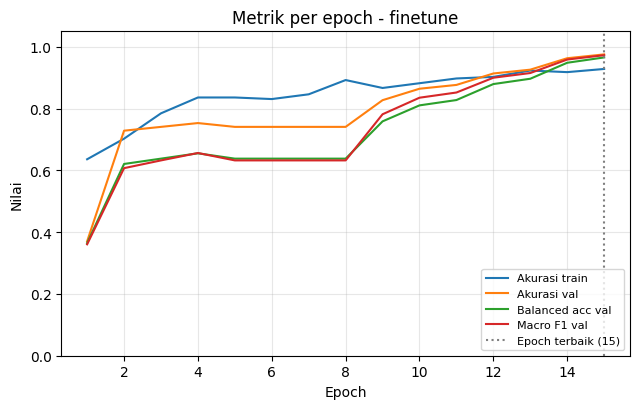

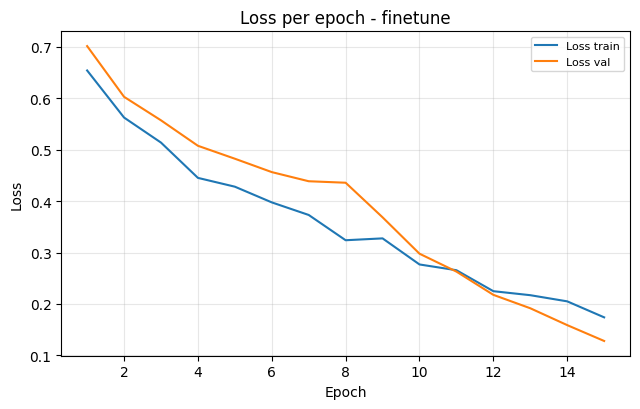

In [17]:
import matplotlib.pyplot as plt

ep = range(1, EPOCHS + 1)
n_m = len(histories)

# Grafik 1: akurasi train, akurasi val, balanced accuracy val, macro F1 val
fig, axes = plt.subplots(1, n_m, figsize=(6.5 * n_m, 4.2), squeeze=False, sharey=True)
for ax, (mode, h) in zip(axes[0], histories.items()):
    ax.plot(ep, h["train_acc"], label="Akurasi train")
    ax.plot(ep, h["val_acc"],   label="Akurasi val")
    ax.plot(ep, h["val_bal"],   label="Balanced acc val")
    ax.plot(ep, h["val_f1"],    label="Macro F1 val")
    be = int(df_info.loc[df_info["mode"] == mode, "best_epoch"].iloc[0])
    ax.axvline(be, color="gray", ls=":", label=f"Epoch terbaik ({be})")
    ax.set_title(f"Metrik per epoch - {mode}"); ax.set_xlabel("Epoch"); ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=8)
axes[0, 0].set_ylabel("Nilai")
plt.tight_layout(); plt.savefig(f"{TAG}_akurasi_per_epoch.png", dpi=150); plt.show()

# Grafik 2: loss train dan val
fig, axes = plt.subplots(1, n_m, figsize=(6.5 * n_m, 4.2), squeeze=False)
for ax, (mode, h) in zip(axes[0], histories.items()):
    ax.plot(ep, h["train_loss"], label="Loss train")
    ax.plot(ep, h["val_loss"],   label="Loss val")
    ax.set_title(f"Loss per epoch - {mode}"); ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0, 0].set_ylabel("Loss")
plt.tight_layout(); plt.savefig(f"{TAG}_loss_per_epoch.png", dpi=150); plt.show()

## 7. Evaluasi validasi dan test
Tabel metrik (loss, akurasi, balanced accuracy, macro F1, recall per kelas) untuk data validasi dan test.

In [18]:
from sklearn.metrics import recall_score

rows, preds = [], {}
for mode, m in trained.items():
    for nama, dl in [("val", val_dl), ("test", test_dl)]:
        y, p, l = evaluate(m, dl)
        preds[(mode, nama)] = (y, p)
        rec = recall_score(y, p, average=None, labels=list(range(NC)), zero_division=0)
        r = {"mode": mode, "split": nama, "loss": round(l, 4),
             "acc": round((y == p).mean(), 4),
             "bal_acc": round(balanced_accuracy_score(y, p), 4),
             "macro_f1": round(f1_score(y, p, average="macro", zero_division=0), 4)}
        r.update({f"recall_{c}": round(x, 4) for c, x in zip(CLASSES, rec)})
        rows.append(r)

df_eval = pd.DataFrame(rows)
print(df_eval.to_string(index=False))
df_eval.to_csv(f"{TAG}_evaluasi_val_test.csv", index=False)

# model terpilih = balanced accuracy VALIDASI tertinggi (test tidak dipakai untuk memilih)
best_mode = df_eval[df_eval.split == "val"].sort_values("bal_acc", ascending=False).iloc[0]["mode"]
print("\nModel terpilih:", best_mode)

    mode split   loss    acc  bal_acc  macro_f1  recall_huruf_angka  recall_panah
finetune   val 0.1281 0.9753   0.9655    0.9727              0.9310           1.0
finetune  test 0.0857 0.9880   0.9902    0.9874              0.9804           1.0

Model terpilih: finetune


## 8. Confusion matrix
Untuk model terpilih, pada data validasi dan test.

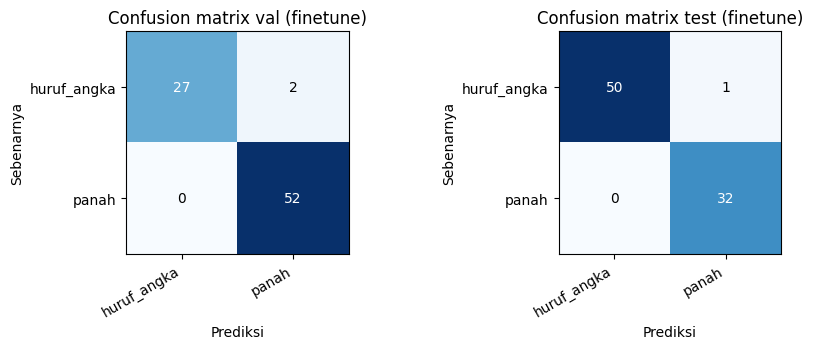

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sz = max(4, 0.6 * NC + 2)
fig, axes = plt.subplots(1, 2, figsize=(2 * sz + 1, sz * 0.9))
for ax, nama in zip(axes, ["val", "test"]):
    y, p = preds[(best_mode, nama)]
    cm = confusion_matrix(y, p, labels=list(range(NC)))
    ax.imshow(cm, cmap="Blues")
    for i in range(NC):
        for j in range(NC):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(NC)); ax.set_xticklabels(CLASSES, rotation=30, ha="right")
    ax.set_yticks(range(NC)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Sebenarnya")
    ax.set_title(f"Confusion matrix {nama} ({best_mode})")
plt.tight_layout(); plt.savefig(f"{TAG}_confusion_matrix.png", dpi=150); plt.show()

## 9. Analisis kesalahan
Daftar gambar test yang salah diprediksi, tingkat keyakinan model, pola kesalahan antar kelas, dan cuplikan gambarnya.

Salah prediksi: 1 dari 83 gambar test (1.2%)
                           nama_file       kelas prediksi  keyakinan
huruf_angka_20261003_terang_0138.jpg huruf_angka    panah      0.551

Pola kesalahan (baris = sebenarnya, kolom = prediksi):
prediksi     panah
kelas             
huruf_angka      1


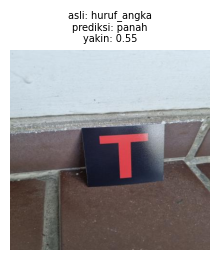

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

def predict_proba(m, dl):
    m.eval(); out = []
    with torch.no_grad():
        for x, _ in dl:
            out.append(torch.softmax(m(x.to(device)), 1).cpu().numpy())
    return np.concatenate(out)

yt, pt = preds[(best_mode, "test")]
prob = predict_proba(trained[best_mode], test_dl)
te_df = df[df.split == "test"].reset_index(drop=True)      # urutan sama dengan test_dl
te_df["prediksi"] = [CLASSES[i] for i in pt]
te_df["keyakinan"] = prob[np.arange(len(pt)), pt].round(3)
salah = te_df[yt != pt]
salah[["nama_file", "kelas", "prediksi", "keyakinan"]].to_csv(f"{TAG}_analisis_kesalahan.csv", index=False)

print(f"Salah prediksi: {len(salah)} dari {len(te_df)} gambar test ({len(salah) / len(te_df) * 100:.1f}%)")
if len(salah):
    print(salah[["nama_file", "kelas", "prediksi", "keyakinan"]].to_string(index=False))
    print("\nPola kesalahan (baris = sebenarnya, kolom = prediksi):")
    print(pd.crosstab(salah.kelas, salah.prediksi))
    n = min(8, len(salah))
    fig, ax = plt.subplots(1, n, figsize=(2.3 * n, 2.8), squeeze=False)
    for a, (_, r) in zip(ax[0], salah.head(n).iterrows()):
        a.imshow(Image.open(r.path).convert("RGB")); a.axis("off")
        a.set_title(f"asli: {r.kelas}\nprediksi: {r.prediksi}\nyakin: {r.keyakinan:.2f}", fontsize=7)
    plt.tight_layout(); plt.show()
else:
    print("Tidak ada kesalahan pada data test.")

## 10. Latensi dan simpan model
Latensi diukur di CPU Colab (satu gambar per prediksi, rata-rata 100 kali).

In [21]:
import os

m_cpu = copy.deepcopy(trained[best_mode]).to("cpu").eval()
x = torch.randn(1, 3, IMG, IMG)
with torch.no_grad():
    for _ in range(20): m_cpu(x)          # pemanasan
    t = []
    for _ in range(100):
        s = time.perf_counter(); m_cpu(x); t.append((time.perf_counter() - s) * 1000)

model_file = f"{TAG}_mobilenetv3_small_{best_mode}.pt"
torch.save(m_cpu.state_dict(), model_file)
print(f"Model terpilih: {best_mode} | latensi rata-rata {np.mean(t):.1f} ms (std {np.std(t):.1f} ms) di CPU Colab "
      f"| ukuran file {os.path.getsize(model_file) / 1e6:.1f} MB")

Model terpilih: finetune | latensi rata-rata 10.6 ms (std 2.7 ms) di CPU Colab | ukuran file 6.2 MB


In [22]:
for f in [f"{TAG}_info_training.csv", f"{TAG}_riwayat_epoch.csv", f"{TAG}_evaluasi_val_test.csv",
          f"{TAG}_analisis_kesalahan.csv", f"{TAG}_akurasi_per_epoch.png", f"{TAG}_loss_per_epoch.png",
          f"{TAG}_confusion_matrix.png", model_file]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# ===== Analisis otomatis + README GitHub =====
# Satu sel: membaca hasil training/evaluasi di atas (TIDAK melatih ulang), menulis analisis,
# lalu membuat README.md ala GitHub + paket repo (zip). Aman dijalankan berulang.
# Ubah GITHUB_USER, REPO_NAME, PROJECT_NAME, dst. di bagian "ISI BAGIAN INI" lebih bawah.
import os, re, math, shutil
from importlib import metadata
import numpy as np, pandas as pd
from IPython.display import Markdown, display

def wilson(k, n, z=1.96):
    """Rentang kepercayaan 95% (Wilson) untuk proporsi k/n."""
    if n == 0:
        return 0.0, 0.0
    p = k / n; d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    a = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return max(0.0, c - a), min(1.0, c + a)

def pct(x):
    return f"{x * 100:.1f}%"

def md_table(d):
    cols = list(d.columns)
    out = ["| " + " | ".join(map(str, cols)) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, r in d.iterrows():
        out.append("| " + " | ".join(str(r[c]) for c in cols) + " |")
    return "\n".join(out)

h   = histories[best_mode]
inf = df_info[df_info["mode"] == best_mode].iloc[0]
ev  = {s: df_eval[(df_eval["mode"] == best_mode) & (df_eval["split"] == s)].iloc[0] for s in ["val", "test"]}
rc  = [c for c in df_eval.columns if c.startswith("recall_")]
be, n_ep = int(inf["best_epoch"]), len(h["val_loss"])
split_n = df.split.value_counts().to_dict()
n_te = split_n.get("test", 0)

L, rek = [], []
def H(judul):
    L.extend(["", f"### {judul}", ""])

# ---------- 1. Data ----------
H("1. Data")
tab = pd.crosstab(df["split"], df["kelas"]).reindex(["train", "val", "test"]).fillna(0).astype(int)
tot_k = df.kelas.value_counts()
L.append(f"- Total **{len(df)}** gambar, **{len(CLASSES)}** kelas ({', '.join(f'`{c}`' for c in CLASSES)}); "
         f"train/val/test = {split_n.get('train', 0)}/{split_n.get('val', 0)}/{n_te}.")
ratio = tot_k.max() / tot_k.min()
if ratio > 3:
    L.append(f"- Kelas **tidak seimbang** (rasio {ratio:.1f}:1). Loss sudah diberi bobot kelas dan hasil dilaporkan dengan balanced accuracy.")
    rek.append("Kelas tidak seimbang: tambah gambar untuk kelas terkecil bila memungkinkan.")
else:
    L.append(f"- Jumlah gambar per kelas relatif seimbang (rasio terbesar:terkecil {ratio:.1f}:1).")
prop = tab.div(tab.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
sel = (prop.loc[["val", "test"]] - prop.loc["train"]).abs()
if sel.max().max() > 0.10:
    s_, k_ = sel.stack().idxmax()
    L.append(f"- Proporsi kelas di **{s_}** berbeda dari train (`{k_}`: {pct(prop.loc[s_, k_])} di {s_} vs {pct(prop.loc['train', k_])} di train). "
             f"Karena itu balanced accuracy dan macro-F1 lebih layak dipercaya daripada akurasi biasa.")
if n_te < 100:
    L.append(f"- Data test hanya **{n_te}** gambar: satu kesalahan setara ±{100 / max(n_te, 1):.1f} poin akurasi, "
             f"jadi selisih kecil antar eksperimen belum tentu bermakna.")
    rek.append(f"Data test kecil ({n_te} gambar). Tambah data test, atau ulangi dengan beberapa seed / cross-validation sebelum menyimpulkan satu model lebih baik dari yang lain.")
if tab.loc["test"].min() < 30:
    k_min = tab.loc["test"].idxmin()
    L.append(f"- Kelas `{k_min}` hanya {tab.loc['test'].min()} gambar di test, sehingga recall kelas ini kasar.")

# ---------- 2. Training ----------
H("2. Proses training")
ta, va, tl, vl = h["train_acc"], h["val_acc"], h["train_loss"], h["val_loss"]
bi = be - 1
L.append(f"- Mode `{best_mode}`: {int(inf['trainable_params']):,} dari {int(inf['total_params']):,} parameter dilatih, "
         f"{n_ep} epoch, {inf['train_time_s']:.0f} detik. Epoch terbaik **{be}/{n_ep}** (balanced accuracy val {inf['best_val_bal_acc']:.3f}).")
if be >= n_ep - 1 and n_ep >= 3 and vl[-1] < vl[-3]:
    L.append(f"- Epoch terbaik jatuh di ujung training dan val loss masih turun ({vl[-3]:.3f} → {vl[-1]:.3f} dalam 2 epoch terakhir): "
             f"model **belum konvergen**, hasil kemungkinan masih bisa membaik dengan epoch lebih banyak.")
    rek.append(f"Naikkan `EPOCHS` (mis. {n_ep * 2}) atau pakai LR scheduler, lalu bandingkan kurva. Training {inf['train_time_s']:.0f} detik, jadi murah dicoba.")
gap = ta[bi] - va[bi]
if gap < -0.02:
    L.append(f"- Akurasi val ({pct(va[bi])}) lebih tinggi dari akurasi train ({pct(ta[bi])}) pada epoch terbaik. Ini lazim bila train memakai "
             f"augmentasi (dan dropout aktif) sedangkan val tidak, ditambah val yang kecil. Bukan tanda overfitting.")
elif gap > 0.10:
    L.append(f"- Jarak train–val besar ({pct(ta[bi])} vs {pct(va[bi])}): indikasi **overfitting**.")
    rek.append("Overfitting: perkuat augmentasi, tambah data, atau tambahkan weight decay / early stopping.")
else:
    L.append(f"- Jarak train–val kecil ({pct(ta[bi])} vs {pct(va[bi])}): tidak ada tanda overfitting.")
j = int(np.argmin(vl))
if vl[-1] > vl[j] * 1.15 and tl[-1] < tl[j]:
    L.append(f"- Val loss terendah di epoch {j + 1} lalu naik lagi sementara train loss terus turun: tanda mulai overfitting.")
if va[0] < 0.6:
    L.append(f"- Epoch 1 masih lemah (akurasi val {pct(va[0])}), wajar karena lapisan klasifikasi baru belum terlatih. Perbaikan terjadi bertahap.")

# ---------- 3. Evaluasi ----------
H("3. Evaluasi validasi dan test")
k_ok = int(round(ev["test"]["acc"] * n_te)); lo, hi = wilson(k_ok, n_te)
L.append(f"- Test: akurasi **{pct(ev['test']['acc'])}**, balanced accuracy **{pct(ev['test']['bal_acc'])}**, macro-F1 **{pct(ev['test']['macro_f1'])}**. "
         f"Rentang kepercayaan 95% (Wilson) akurasi test: **{pct(lo)} – {pct(hi)}** ({k_ok}/{n_te} benar).")
d = ev["test"]["bal_acc"] - ev["val"]["bal_acc"]
if abs(d) <= 0.05:
    L.append(f"- Val dan test konsisten (selisih balanced accuracy {abs(d) * 100:.1f} poin).")
elif d < 0:
    L.append(f"- Test lebih rendah dari val sebesar {abs(d) * 100:.1f} poin: kemungkinan epoch terpilih agak menyesuaikan diri ke val, atau distribusi test berbeda.")
else:
    L.append(f"- Test lebih tinggi dari val sebesar {d * 100:.1f} poin. Epoch dipilih memakai val saja, jadi test tetap independen. "
             f"Selisih ini lebih mungkin berasal dari ukuran dan komposisi data yang kecil daripada dari kelebihan model.")
for s in ["val", "test"]:
    r = {c[7:]: ev[s][c] for c in rc}
    kmin = min(r, key=r.get)
    if r[kmin] < 1.0:
        L.append(f"- Recall terendah di **{s}**: `{kmin}` ({pct(r[kmin])}).")

# ---------- 4. Kesalahan ----------
H("4. Analisis kesalahan (data test)")
if "salah" in globals() and "te_df" in globals() and "yt" in globals():
    if len(salah) == 0:
        L.append("- Tidak ada kesalahan prediksi pada data test.")
    else:
        benar = te_df[yt == pt]
        pas = salah.groupby(["kelas", "prediksi"]).size().sort_values(ascending=False)
        (a_, b_), n_ab = pas.index[0], int(pas.iloc[0])
        L.append(f"- **{len(salah)}** dari {len(te_df)} gambar test salah ({pct(len(salah) / len(te_df))}). Arah kesalahan terbanyak: `{a_}` → `{b_}` ({n_ab}×).")
        L.append(f"- Keyakinan rata-rata saat salah {salah.keyakinan.mean():.2f}, saat benar {benar.keyakinan.mean():.2f}.")
        ragu = int((salah.keyakinan < 0.6).sum()); yakin = int((salah.keyakinan >= 0.8).sum())
        if ragu == len(salah):
            L.append("- Semua kesalahan berkeyakinan rendah (< 0.6): model ragu, bukan salah dengan yakin. Ambang keyakinan bisa dipakai untuk menandai prediksi yang perlu dicek ulang.")
        elif yakin:
            L.append(f"- {yakin} kesalahan berkeyakinan tinggi (≥ 0.8): periksa kemungkinan label salah atau gambar yang menyesatkan.")
        L.append("- File yang salah: " + ", ".join(f"`{n}`" for n in salah.nama_file.head(5)) + (" …" if len(salah) > 5 else "") + ".")
        rek.append("Buka gambar yang salah (cuplikan di bagian Analisis kesalahan) dan cek: label salah? objek kecil, blur, atau terlalu gelap/terang? Bila kondisinya sama, tambah data pada kondisi itu.")
else:
    L.append("- (Jalankan sel Analisis kesalahan di atas dulu agar bagian ini terisi.)")

# ---------- 5. Latensi ----------
H("5. Latensi dan ukuran model")
if "t" in globals() and isinstance(t, list) and len(t):
    tt = np.array(t); sz = os.path.getsize(model_file) / 1e6
    L.append(f"- CPU Colab, 1 gambar {IMG}×{IMG}: rata-rata **{tt.mean():.1f} ms**, median {np.median(tt):.1f} ms, p95 {np.percentile(tt, 95):.1f} ms (std {tt.std():.1f}). Ukuran file model {sz:.1f} MB.")
    if tt.std() > 0.5 * tt.mean():
        L.append("- Variasi latensi besar (CPU Colab dipakai bersama), jadi median atau p95 lebih representatif daripada rata-rata.")
    L.append("- Yang diukur hanya forward pass pada input acak. Belum termasuk baca gambar, resize, normalisasi, dan bukan perangkat target.")
    rek.append("Bila model akan dipasang di perangkat tertentu (mis. Raspberry Pi / HP), ukur ulang latensi di sana dengan pipeline lengkap.")
else:
    L.append("- (Jalankan sel Latensi di atas dulu agar bagian ini terisi.)")

# ---------- 6. Rekomendasi ----------
if len(histories) == 1:
    rek.append(f"Baru satu mode (`{best_mode}`) yang dilatih. Kalau perlu bukti manfaat transfer learning, isi `MODES = [\"scratch\", \"freeze\", \"finetune\"]` di sel training lalu latih ulang.")
rek.append("Pastikan foto dari sesi pengambilan yang sama tidak terpecah ke train dan test. Kalau terpecah, angka test terlihat lebih bagus dari kemampuan sebenarnya.")
H("6. Rekomendasi")
L.extend(f"{i}. {r}" for i, r in enumerate(rek, 1))

analisis_md = "\n".join(L).strip()
with open(f"{TAG}_analisis.md", "w", encoding="utf-8") as f:
    f.write(analisis_md + "\n")
display(Markdown("## Analisis otomatis\n\n" + analisis_md))
print(f"\nTersimpan: {TAG}_analisis.md")

# ======================= README GITHUB =======================

# ---------- ISI BAGIAN INI ----------
GITHUB_USER   = "username-kamu"
REPO_NAME     = "nama-repo"
PROJECT_NAME  = "Klasifikasi Gambar dengan MobileNetV3-Small"
DESKRIPSI     = ""        # kosongkan untuk deskripsi otomatis
AUTHOR        = ""        # nama kamu (opsional)
LISENSI       = "MIT"     # kosongkan kalau belum menentukan lisensi
NOTEBOOK_NAME = "transfer_learning_finetune.ipynb"   # nama notebook yang kamu taruh di repo
# ------------------------------------

def ver(p):
    try:
        return metadata.version(p).split("+")[0]
    except Exception:
        return None

pack = f"github_pack_{TAG}"
shutil.rmtree(pack, ignore_errors=True)
for d_ in ["images", "results", "models"]:
    os.makedirs(f"{pack}/{d_}")

def cp(src, dst):
    if os.path.exists(src):
        shutil.copy(src, f"{pack}/{dst}")
        return True
    print("dilewati (file tidak ada):", src)
    return False

img_ok = {n: cp(f"{TAG}_{n}.png", f"images/{n}.png") for n in ["akurasi_per_epoch", "loss_per_epoch", "confusion_matrix"]}
for n in ["info_training", "riwayat_epoch", "evaluasi_val_test", "analisis_kesalahan"]:
    cp(f"{TAG}_{n}.csv", f"results/{n}.csv")
cp(f"{TAG}_analisis.md", "results/analisis.md")
model_name = os.path.basename(model_file)
cp(model_file, f"models/{model_name}")

reqs = []
for p in ["torch", "torchvision", "scikit-learn", "pandas", "numpy", "matplotlib", "pillow"]:
    v = ver(p)
    reqs.append(f"{p}>={v}" if v else p)
with open(f"{pack}/requirements.txt", "w") as f:
    f.write("\n".join(reqs) + "\n")

# ---------- bahan README ----------
ev  = {s: df_eval[(df_eval["mode"] == best_mode) & (df_eval["split"] == s)].iloc[0] for s in ["val", "test"]}
inf = df_info[df_info["mode"] == best_mode].iloc[0]
rc  = [c for c in df_eval.columns if c.startswith("recall_")]

def badge(label, msg, color):
    q = lambda s: s.replace("-", "--").replace("_", "__").replace(" ", "_").replace("%", "%25")
    return f"![{label}](https://img.shields.io/badge/{q(label)}-{q(msg)}-{color})"

fmt = lambda v, p: pct(v) if p else f"{v:.4f}"
rows = [("Loss", "loss", False), ("Accuracy", "acc", True), ("Balanced accuracy", "bal_acc", True), ("Macro F1", "macro_f1", True)]
rows += [(f"Recall `{c[7:]}`", c, True) for c in rc]
hasil = pd.DataFrame({"Metrik": [r[0] for r in rows],
                      "Validasi": [fmt(ev["val"][r[1]], r[2]) for r in rows],
                      "Test": [fmt(ev["test"][r[1]], r[2]) for r in rows]})

tb = pd.crosstab(df.split, df.kelas).reindex(["train", "val", "test"]).fillna(0).astype(int)
tb["Total"] = tb.sum(axis=1); tb.loc["Total"] = tb.sum()
tb.columns.name = None; tb.index.name = "Split"
tb = tb.reset_index()

hp = [("Arsitektur", "MobileNetV3-Small (torchvision)"),
      ("Mode", f"`{best_mode}`" + (" (bobot awal ImageNet, semua lapisan dilatih)" if best_mode == "finetune" else "")),
      ("Parameter dilatih", f"{int(inf['trainable_params']):,} / {int(inf['total_params']):,}"),
      ("Optimizer", f"Adam, lr = {LR[best_mode]}"),
      ("Epoch / batch size", f"{EPOCHS} / {BS}"),
      ("Ukuran input", f"{IMG} × {IMG}"),
      ("Loss", "CrossEntropy berbobot kelas"),
      ("Pemilihan epoch", f"balanced accuracy validasi tertinggi (epoch {int(inf['best_epoch'])})"),
      ("Seed", str(SEED)),
      ("Perangkat training", str(device)),
      ("Waktu training", f"{inf['train_time_s']:.0f} detik")]
hp = pd.DataFrame(hp, columns=["Pengaturan", "Nilai"])

deskripsi = DESKRIPSI or (f"Klasifikasi gambar {len(CLASSES)} kelas ({', '.join(CLASSES)}) memakai transfer learning "
                          f"MobileNetV3-Small di PyTorch. Akurasi test {pct(ev['test']['acc'])} "
                          f"(balanced accuracy {pct(ev['test']['bal_acc'])}) pada {len(df[df.split == 'test'])} gambar test.")

R = []; A = R.append
A(f"# {PROJECT_NAME}")
A("")
A(" ".join([
    badge("python", "3.x", "blue"),
    badge("PyTorch", ver("torch") or "-", "ee4c2c"),
    badge("test acc", pct(ev["test"]["acc"]), "brightgreen"),
    badge("balanced acc", pct(ev["test"]["bal_acc"]), "brightgreen"),
    badge("license", LISENSI, "lightgrey") if LISENSI else "",
]).strip())
A("")
A(f"[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/{GITHUB_USER}/{REPO_NAME}/blob/main/{NOTEBOOK_NAME})")
A("")
A(deskripsi)
A("")
A("## Daftar isi")
A("- [Hasil](#hasil)\n- [Dataset](#dataset)\n- [Model dan training](#model-dan-training)\n- [Grafik](#grafik)\n- [Analisis](#analisis)\n- [Cara memakai model](#cara-memakai-model)\n- [Menjalankan ulang](#menjalankan-ulang)\n- [Struktur repo](#struktur-repo)")
A("")
A("## Hasil")
A("")
A(f"Model terpilih: `{best_mode}`, dipilih dari balanced accuracy **validasi** (data test tidak dipakai untuk memilih).")
A("")
A(md_table(hasil))
A("")
A(f"Latensi CPU Colab: {np.mean(t):.1f} ms per gambar (median {np.median(t):.1f} ms), ukuran model {os.path.getsize(model_file) / 1e6:.1f} MB." if "t" in globals() and isinstance(t, list) and len(t) else "")
A("")
A("## Dataset")
A("")
A(f"Jumlah gambar per split dan kelas ({len(df)} gambar):")
A("")
A(md_table(tb))
A("")
A("Transformasi data training (diambil langsung dari kode):")
A("")
A("```text\n" + str(tf_train) + "\n```")
A("")
A("## Model dan training")
A("")
A(md_table(hp))
A("")
if any(img_ok.values()):
    A("## Grafik")
    A("")
    if img_ok["akurasi_per_epoch"]: A("![Metrik per epoch](images/akurasi_per_epoch.png)\n")
    if img_ok["loss_per_epoch"]:    A("![Loss per epoch](images/loss_per_epoch.png)\n")
    if img_ok["confusion_matrix"]:  A("![Confusion matrix](images/confusion_matrix.png)\n")
A("## Analisis")
A("")
A(analisis_md)
A("")
A("## Cara memakai model")
A("")
A("```python")
A("import torch, torch.nn as nn")
A("from PIL import Image")
A("from torchvision import models, transforms")
A("")
A(f"CLASSES = {CLASSES!r}")
A(f"IMG = {IMG}")
A("")
A("model = models.mobilenet_v3_small(weights=None)")
A("model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(CLASSES))")
A(f"model.load_state_dict(torch.load(\"models/{model_name}\", map_location=\"cpu\"))")
A("model.eval()")
A("")
A("tf = transforms.Compose([transforms.Resize((IMG, IMG)), transforms.ToTensor(),")
A("                         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])")
A("x = tf(Image.open(\"contoh.jpg\").convert(\"RGB\")).unsqueeze(0)")
A("with torch.no_grad():")
A("    probs = torch.softmax(model(x), 1)[0]")
A("print(CLASSES[probs.argmax().item()], float(probs.max()))")
A("```")
A("")
A("## Menjalankan ulang")
A("")
A(f"1. Buka notebook `{NOTEBOOK_NAME}` di Google Colab (tombol di atas), lalu pilih **Runtime → Change runtime type → T4 GPU**.")
A("2. Jalankan sel dari atas ke bawah dan unggah zip dataset ketika diminta. Kelas dan pembagian train/val/test dideteksi otomatis.")
A("3. Untuk lingkungan lokal: `pip install -r requirements.txt`.")
A("")
A("## Struktur repo")
A("")
A("```text")
A(f"{REPO_NAME}/\n├── README.md\n├── requirements.txt\n├── {NOTEBOOK_NAME}\n├── images/    # grafik training dan confusion matrix\n├── results/   # CSV metrik, riwayat epoch, analisis kesalahan\n└── models/    # bobot model (.pt)")
A("```")
if LISENSI or AUTHOR:
    A("")
    if LISENSI:
        A(f"## Lisensi\n\n{LISENSI}. Tambahkan file `LICENSE` ke repo.")
        A("")
    if AUTHOR:
        A(f"## Penulis\n\n{AUTHOR}")

readme = re.sub(r"\n{3,}", "\n\n", "\n".join(R)).strip() + "\n"
with open(f"{pack}/README.md", "w", encoding="utf-8") as f:
    f.write(readme)
shutil.copy(f"{pack}/README.md", f"{TAG}_README.md")
shutil.make_archive(f"{TAG}_github_pack", "zip", pack)

print("Isi paket repo:")
for dp, dn, fn in sorted(os.walk(pack)):
    for x in sorted(fn):
        print("  ", os.path.join(dp, x).replace(pack + os.sep, ""))
print(f"\nTersimpan: {TAG}_README.md dan {TAG}_github_pack.zip")
print("Gambar tidak tampil di pratinjau ini; akan tampil setelah README di-push ke GitHub.\n")
display(Markdown(re.sub(r"!\[[^\]]*\]\([^)]*\)\n?", "", readme)))

try:
    from google.colab import files
    for f_ in [f"{TAG}_README.md", f"{TAG}_github_pack.zip", f"{TAG}_analisis.md"]:
        if os.path.exists(f_):
            files.download(f_)
except ImportError:
    pass

## Analisis otomatis

### 1. Data

- Total **359** gambar, **2** kelas (`huruf_angka`, `panah`); train/val/test = 195/81/83.
- Jumlah gambar per kelas relatif seimbang (rasio terbesar:terkecil 1.0:1).
- Proporsi kelas di **val** berbeda dari train (`huruf_angka`: 35.8% di val vs 51.3% di train). Karena itu balanced accuracy dan macro-F1 lebih layak dipercaya daripada akurasi biasa.
- Data test hanya **83** gambar: satu kesalahan setara ±1.2 poin akurasi, jadi selisih kecil antar eksperimen belum tentu bermakna.

### 2. Proses training

- Mode `finetune`: 1,519,906 dari 1,519,906 parameter dilatih, 15 epoch, 27 detik. Epoch terbaik **15/15** (balanced accuracy val 0.966).
- Epoch terbaik jatuh di ujung training dan val loss masih turun (0.192 → 0.128 dalam 2 epoch terakhir): model **belum konvergen**, hasil kemungkinan masih bisa membaik dengan epoch lebih banyak.
- Akurasi val (97.5%) lebih tinggi dari akurasi train (92.8%) pada epoch terbaik. Ini lazim bila train memakai augmentasi (dan dropout aktif) sedangkan val tidak, ditambah val yang kecil. Bukan tanda overfitting.
- Epoch 1 masih lemah (akurasi val 37.0%), wajar karena lapisan klasifikasi baru belum terlatih. Perbaikan terjadi bertahap.

### 3. Evaluasi validasi dan test

- Test: akurasi **98.8%**, balanced accuracy **99.0%**, macro-F1 **98.7%**. Rentang kepercayaan 95% (Wilson) akurasi test: **93.5% – 99.8%** (82/83 benar).
- Val dan test konsisten (selisih balanced accuracy 2.5 poin).
- Recall terendah di **val**: `huruf_angka` (93.1%).
- Recall terendah di **test**: `huruf_angka` (98.0%).

### 4. Analisis kesalahan (data test)

- **1** dari 83 gambar test salah (1.2%). Arah kesalahan terbanyak: `huruf_angka` → `panah` (1×).
- Keyakinan rata-rata saat salah 0.55, saat benar 0.93.
- Semua kesalahan berkeyakinan rendah (< 0.6): model ragu, bukan salah dengan yakin. Ambang keyakinan bisa dipakai untuk menandai prediksi yang perlu dicek ulang.
- File yang salah: `huruf_angka_20261003_terang_0138.jpg`.

### 5. Latensi dan ukuran model

- CPU Colab, 1 gambar 224×224: rata-rata **10.6 ms**, median 9.6 ms, p95 18.1 ms (std 2.7). Ukuran file model 6.2 MB.
- Yang diukur hanya forward pass pada input acak. Belum termasuk baca gambar, resize, normalisasi, dan bukan perangkat target.

### 6. Rekomendasi

1. Data test kecil (83 gambar). Tambah data test, atau ulangi dengan beberapa seed / cross-validation sebelum menyimpulkan satu model lebih baik dari yang lain.
2. Naikkan `EPOCHS` (mis. 30) atau pakai LR scheduler, lalu bandingkan kurva. Training 27 detik, jadi murah dicoba.
3. Buka gambar yang salah (cuplikan di bagian Analisis kesalahan) dan cek: label salah? objek kecil, blur, atau terlalu gelap/terang? Bila kondisinya sama, tambah data pada kondisi itu.
4. Bila model akan dipasang di perangkat tertentu (mis. Raspberry Pi / HP), ukur ulang latensi di sana dengan pipeline lengkap.
5. Baru satu mode (`finetune`) yang dilatih. Kalau perlu bukti manfaat transfer learning, isi `MODES = ["scratch", "freeze", "finetune"]` di sel training lalu latih ulang.
6. Pastikan foto dari sesi pengambilan yang sama tidak terpecah ke train dan test. Kalau terpecah, angka test terlihat lebih bagus dari kemampuan sebenarnya.


Tersimpan: dataset_raw_1_analisis.md
Isi paket repo:
   README.md
   requirements.txt
   images/akurasi_per_epoch.png
   images/confusion_matrix.png
   images/loss_per_epoch.png
   models/dataset_raw_1_mobilenetv3_small_finetune.pt
   results/analisis.md
   results/analisis_kesalahan.csv
   results/evaluasi_val_test.csv
   results/info_training.csv
   results/riwayat_epoch.csv

Tersimpan: dataset_raw_1_README.md dan dataset_raw_1_github_pack.zip
Gambar tidak tampil di pratinjau ini; akan tampil setelah README di-push ke GitHub.



# Klasifikasi Gambar dengan MobileNetV3-Small

    
[](https://colab.research.google.com/github/username-kamu/nama-repo/blob/main/transfer_learning_finetune.ipynb)

Klasifikasi gambar 2 kelas (huruf_angka, panah) memakai transfer learning MobileNetV3-Small di PyTorch. Akurasi test 98.8% (balanced accuracy 99.0%) pada 83 gambar test.

## Daftar isi
- [Hasil](#hasil)
- [Dataset](#dataset)
- [Model dan training](#model-dan-training)
- [Grafik](#grafik)
- [Analisis](#analisis)
- [Cara memakai model](#cara-memakai-model)
- [Menjalankan ulang](#menjalankan-ulang)
- [Struktur repo](#struktur-repo)

## Hasil

Model terpilih: `finetune`, dipilih dari balanced accuracy **validasi** (data test tidak dipakai untuk memilih).

| Metrik | Validasi | Test |
|---|---|---|
| Loss | 0.1281 | 0.0857 |
| Accuracy | 97.5% | 98.8% |
| Balanced accuracy | 96.5% | 99.0% |
| Macro F1 | 97.3% | 98.7% |
| Recall `huruf_angka` | 93.1% | 98.0% |
| Recall `panah` | 100.0% | 100.0% |

Latensi CPU Colab: 10.6 ms per gambar (median 9.6 ms), ukuran model 6.2 MB.

## Dataset

Jumlah gambar per split dan kelas (359 gambar):

| Split | huruf_angka | panah | Total |
|---|---|---|---|
| train | 100 | 95 | 195 |
| val | 29 | 52 | 81 |
| test | 51 | 32 | 83 |
| Total | 180 | 179 | 359 |

Transformasi data training (diambil langsung dari kode):

```text
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomAffine(degrees=[-8.0, 8.0], translate=(0.05, 0.05), scale=(0.9, 1.1))
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
```

## Model dan training

| Pengaturan | Nilai |
|---|---|
| Arsitektur | MobileNetV3-Small (torchvision) |
| Mode | `finetune` (bobot awal ImageNet, semua lapisan dilatih) |
| Parameter dilatih | 1,519,906 / 1,519,906 |
| Optimizer | Adam, lr = 0.0001 |
| Epoch / batch size | 15 / 32 |
| Ukuran input | 224 × 224 |
| Loss | CrossEntropy berbobot kelas |
| Pemilihan epoch | balanced accuracy validasi tertinggi (epoch 15) |
| Seed | 42 |
| Perangkat training | cuda |
| Waktu training | 27 detik |

## Grafik




## Analisis

### 1. Data

- Total **359** gambar, **2** kelas (`huruf_angka`, `panah`); train/val/test = 195/81/83.
- Jumlah gambar per kelas relatif seimbang (rasio terbesar:terkecil 1.0:1).
- Proporsi kelas di **val** berbeda dari train (`huruf_angka`: 35.8% di val vs 51.3% di train). Karena itu balanced accuracy dan macro-F1 lebih layak dipercaya daripada akurasi biasa.
- Data test hanya **83** gambar: satu kesalahan setara ±1.2 poin akurasi, jadi selisih kecil antar eksperimen belum tentu bermakna.

### 2. Proses training

- Mode `finetune`: 1,519,906 dari 1,519,906 parameter dilatih, 15 epoch, 27 detik. Epoch terbaik **15/15** (balanced accuracy val 0.966).
- Epoch terbaik jatuh di ujung training dan val loss masih turun (0.192 → 0.128 dalam 2 epoch terakhir): model **belum konvergen**, hasil kemungkinan masih bisa membaik dengan epoch lebih banyak.
- Akurasi val (97.5%) lebih tinggi dari akurasi train (92.8%) pada epoch terbaik. Ini lazim bila train memakai augmentasi (dan dropout aktif) sedangkan val tidak, ditambah val yang kecil. Bukan tanda overfitting.
- Epoch 1 masih lemah (akurasi val 37.0%), wajar karena lapisan klasifikasi baru belum terlatih. Perbaikan terjadi bertahap.

### 3. Evaluasi validasi dan test

- Test: akurasi **98.8%**, balanced accuracy **99.0%**, macro-F1 **98.7%**. Rentang kepercayaan 95% (Wilson) akurasi test: **93.5% – 99.8%** (82/83 benar).
- Val dan test konsisten (selisih balanced accuracy 2.5 poin).
- Recall terendah di **val**: `huruf_angka` (93.1%).
- Recall terendah di **test**: `huruf_angka` (98.0%).

### 4. Analisis kesalahan (data test)

- **1** dari 83 gambar test salah (1.2%). Arah kesalahan terbanyak: `huruf_angka` → `panah` (1×).
- Keyakinan rata-rata saat salah 0.55, saat benar 0.93.
- Semua kesalahan berkeyakinan rendah (< 0.6): model ragu, bukan salah dengan yakin. Ambang keyakinan bisa dipakai untuk menandai prediksi yang perlu dicek ulang.
- File yang salah: `huruf_angka_20261003_terang_0138.jpg`.

### 5. Latensi dan ukuran model

- CPU Colab, 1 gambar 224×224: rata-rata **10.6 ms**, median 9.6 ms, p95 18.1 ms (std 2.7). Ukuran file model 6.2 MB.
- Yang diukur hanya forward pass pada input acak. Belum termasuk baca gambar, resize, normalisasi, dan bukan perangkat target.

### 6. Rekomendasi

1. Data test kecil (83 gambar). Tambah data test, atau ulangi dengan beberapa seed / cross-validation sebelum menyimpulkan satu model lebih baik dari yang lain.
2. Naikkan `EPOCHS` (mis. 30) atau pakai LR scheduler, lalu bandingkan kurva. Training 27 detik, jadi murah dicoba.
3. Buka gambar yang salah (cuplikan di bagian Analisis kesalahan) dan cek: label salah? objek kecil, blur, atau terlalu gelap/terang? Bila kondisinya sama, tambah data pada kondisi itu.
4. Bila model akan dipasang di perangkat tertentu (mis. Raspberry Pi / HP), ukur ulang latensi di sana dengan pipeline lengkap.
5. Baru satu mode (`finetune`) yang dilatih. Kalau perlu bukti manfaat transfer learning, isi `MODES = ["scratch", "freeze", "finetune"]` di sel training lalu latih ulang.
6. Pastikan foto dari sesi pengambilan yang sama tidak terpecah ke train dan test. Kalau terpecah, angka test terlihat lebih bagus dari kemampuan sebenarnya.

## Cara memakai model

```python
import torch, torch.nn as nn
from PIL import Image
from torchvision import models, transforms

CLASSES = ['huruf_angka', 'panah']
IMG = 224

model = models.mobilenet_v3_small(weights=None)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(CLASSES))
model.load_state_dict(torch.load("models/dataset_raw_1_mobilenetv3_small_finetune.pt", map_location="cpu"))
model.eval()

tf = transforms.Compose([transforms.Resize((IMG, IMG)), transforms.ToTensor(),
                         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
x = tf(Image.open("contoh.jpg").convert("RGB")).unsqueeze(0)
with torch.no_grad():
    probs = torch.softmax(model(x), 1)[0]
print(CLASSES[probs.argmax().item()], float(probs.max()))
```

## Menjalankan ulang

1. Buka notebook `transfer_learning_finetune.ipynb` di Google Colab (tombol di atas), lalu pilih **Runtime → Change runtime type → T4 GPU**.
2. Jalankan sel dari atas ke bawah dan unggah zip dataset ketika diminta. Kelas dan pembagian train/val/test dideteksi otomatis.
3. Untuk lingkungan lokal: `pip install -r requirements.txt`.

## Struktur repo

```text
nama-repo/
├── README.md
├── requirements.txt
├── transfer_learning_finetune.ipynb
├── images/    # grafik training dan confusion matrix
├── results/   # CSV metrik, riwayat epoch, analisis kesalahan
└── models/    # bobot model (.pt)
```

## Lisensi

MIT. Tambahkan file `LICENSE` ke repo.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>